# 12i — Extreme-Value Distributions for Hazard Modeling

Covers `chap12_statistical_modeling1a-c`: three families of probability
distribution commonly used to model hazard intensities (e.g. wind speed) —
Gaussian, Weibull, and Generalized Extreme Value (GEV) — their moments,
density shapes, and return-period/quantile relationships.

**Custom-function note:** the source scripts call `pdfweibull`, `pdfgev`,
`cdfweibull`, `cdfweibulli`, `cdfgev`, `cdfgevi`, and `skewness_weibull`,
none of which exist anywhere in the shipped archive (confirmed by an
exact and case-insensitive filename/function-definition search across
`QuantToolbox/` and `HSF/0. Toolbox/`). They follow the same `pdf<dist>`/
`cdf<dist>`/`cdf<dist>i` naming convention as the *found* `pdfn`/`cdfn`/
`cdfni` (Gaussian pdf/cdf/quantile, ported below from their known
closed forms), so they are reimplemented here directly from the
textbook Weibull/GEV formulas. This is provably low-risk: `1b`/`1c`
themselves cross-check the "custom" Weibull/GEV functions against
MATLAB's *built-in* `wblpdf`/`gevpdf`, confirming these are standard
closed-form distributions and not some idiosyncratic house convention —
the same cross-check is reproduced below against `scipy.stats`.

**MATLAB parameter-convention notes** (easy to get wrong silently):
- `makedist("Weibull",A,B)` / the custom `pdfweibull`/`cdfweibull*` use
  `(scale=A, shape=B)` — i.e. `scipy.stats.weibull_min(c=B, scale=A)`.
- `makedist("GeneralizedExtremeValue",xi,sigma,mu)` and the custom
  `pdfgev`/`cdfgev*` use `(shape ξ, scale σ, location μ)`, but MATLAB's
  *builtin* `gevpdf(x,k,sigma,mu)` cross-check call in `1b` passes the
  shape as its 2nd argument (`k=xi_gev`) — same convention, just
  positioned differently. **scipy's GEV shape parameter is negated**
  relative to MATLAB's ξ convention: `scipy.stats.genextreme(c=-xi,
  loc=mu, scale=sigma)` is the equivalent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf, erfinv, gamma
from scipy import stats

color_blue  = "#1f77b4"
color_red   = "#d62728"
color_green = "#2ca02c"

plt.rcParams["figure.dpi"] = 100


## 0. Custom-function reimplementations

`pdfn`/`cdfn`/`cdfni` (Gaussian pdf/cdf/quantile) are found in
`QuantToolbox/` and ported directly from their standard closed forms.
`pdfweibull`/`cdfweibull`/`cdfweibulli` and `pdfgev`/`cdfgev`/`cdfgevi`
and `skewness_weibull` are the genuinely-missing functions, reimplemented
from the textbook Weibull/GEV formulas as described above.

In [2]:
def pdfn(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def cdfn(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    return 0.5 * (1 + erf((x - mu) / (sigma * np.sqrt(2))))


def cdfni(p):
    p = np.asarray(p, dtype=float)
    return np.sqrt(2) * erfinv(2 * p - 1)


def pdfweibull(x, alpha, beta):
    # scale=alpha, shape=beta
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x >= 0
    out[mask] = (beta / alpha) * (x[mask] / alpha) ** (beta - 1) * np.exp(-(x[mask] / alpha) ** beta)
    return out


def cdfweibull(x, alpha, beta):
    x = np.asarray(x, dtype=float)
    return np.where(x >= 0, 1 - np.exp(-(x / alpha) ** beta), 0.0)


def cdfweibulli(p, alpha, beta):
    # inverse cdf (quantile function)
    p = np.asarray(p, dtype=float)
    return alpha * (-np.log(1 - p)) ** (1 / beta)


def skewness_weibull(alpha, beta):
    # standard closed form via raw moments of the Weibull(scale=alpha, shape=beta)
    g1, g2, g3 = gamma(1 + 1 / beta), gamma(1 + 2 / beta), gamma(1 + 3 / beta)
    mean = alpha * g1
    var = alpha ** 2 * (g2 - g1 ** 2)
    ex3 = alpha ** 3 * g3
    m3 = ex3 - 3 * mean * var - mean ** 3  # E[(X-mean)^3]
    return m3 / var ** 1.5


def pdfgev(x, mu, sigma, xi):
    # location=mu, scale=sigma, shape=xi
    x = np.asarray(x, dtype=float)
    if xi == 0:
        z = (x - mu) / sigma
        t = np.exp(-z)
    else:
        z = 1 + xi * (x - mu) / sigma
        t = z ** (-1 / xi)
    return (1 / sigma) * t ** (xi + 1) * np.exp(-t)


def cdfgev(x, mu, sigma, xi):
    x = np.asarray(x, dtype=float)
    if xi == 0:
        z = (x - mu) / sigma
        return np.exp(-np.exp(-z))
    z = 1 + xi * (x - mu) / sigma
    return np.exp(-z ** (-1 / xi))


def cdfgevi(p, mu, sigma, xi):
    # inverse cdf (quantile function)
    p = np.asarray(p, dtype=float)
    if xi == 0:
        return mu - sigma * np.log(-np.log(p))
    return mu + sigma / xi * ((-np.log(p)) ** (-xi) - 1)


## 1. Distribution moments (`chap12_statistical_modeling1a`)

Mean and standard deviation of three hazard-intensity distributions
(Gaussian, Weibull, GEV), fit with illustrative parameter sets meant to
represent a wind-speed-like variable (km/h).

In [3]:
mu_gaussian, sigma_gaussian = 250, 20
alpha_weibull, beta_weibull = 280, 14
mu_gev, sigma_gev, xi_gev = 240, 16, 0.15

pd1 = stats.norm(loc=mu_gaussian, scale=sigma_gaussian)
pd2 = stats.weibull_min(c=beta_weibull, scale=alpha_weibull)
pd3 = stats.genextreme(c=-xi_gev, loc=mu_gev, scale=sigma_gev)

moments = pd.DataFrame({
    "Mean": [pd1.mean(), pd2.mean(), pd3.mean()],
    "Std dev": [pd1.std(), pd2.std(), pd3.std()],
}, index=["Gaussian", "Weibull", "GEV"])
display(moments.round(3))


,Mean,Std dev
Gaussian,250.000,20.000
Weibull,269.783,23.571
GEV,251.998,26.222


## 2. PDF comparison and Weibull skewness (`chap12_statistical_modeling1b`)

The three densities plotted together over a common wind-speed axis, with
the "custom" Weibull/GEV pdf implementations cross-checked against
`scipy.stats`' built-in `weibull_min`/`genextreme` (the same cross-check
the source script runs against MATLAB's `wblpdf`/`gevpdf`), plus the
Weibull distribution's skewness coefficient.

Weibull skewness: -0.7651
scipy.stats cross-check: -0.7651
max|pdfweibull - scipy weibull_min.pdf| = 3.469446951953614e-18
max|pdfgev - scipy genextreme.pdf|      = 1.5612511283791264e-17


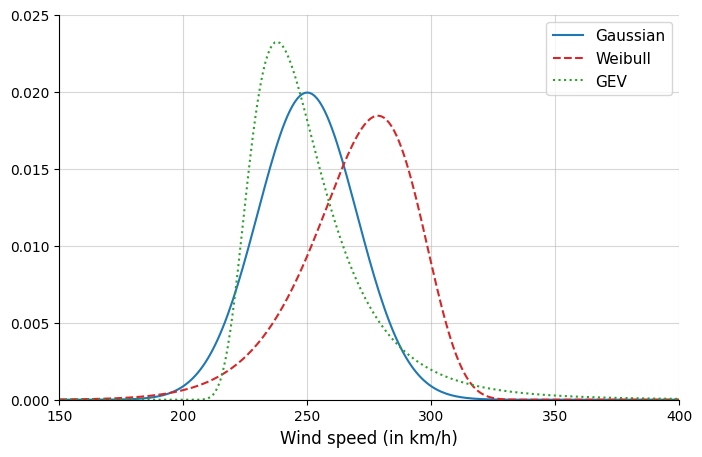

In [4]:
skew = skewness_weibull(alpha_weibull, beta_weibull)
print(f"Weibull skewness: {skew:.4f}")
print(f"scipy.stats cross-check: {pd2.stats('s'):.4f}")

x = np.arange(150, 401, 1.0)

pdf1 = pdfn(x, mu_gaussian, sigma_gaussian)
pdf2 = pdfweibull(x, alpha_weibull, beta_weibull)
pdf2b = pd2.pdf(x)
print("max|pdfweibull - scipy weibull_min.pdf| =", np.max(np.abs(pdf2 - pdf2b)))

pdf3 = pdfgev(x, mu_gev, sigma_gev, xi_gev)
pdf3b = pd3.pdf(x)
print("max|pdfgev - scipy genextreme.pdf|      =", np.max(np.abs(pdf3 - pdf3b)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, pdf1, "-", color=color_blue, linewidth=1.5, label="Gaussian")
ax.plot(x, pdf2, "--", color=color_red, linewidth=1.5, label="Weibull")
ax.plot(x, pdf3, ":", color=color_green, linewidth=1.5, label="GEV")

ax.set_xlabel("Wind speed (in km/h)", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(150, 400)
ax.set_ylim(0, 0.025)
plt.show()


## 3. Return periods and quantiles (`chap12_statistical_modeling1c`)

For three wind speeds `w = [300, 310, 320]`, the exceedance probability
and implied return period under each of the 3 distributions; and,
independently, for three confidence levels `alpha = [0.95, 0.99, 0.999]`,
the corresponding quantile with a forward/inverse round-trip consistency
check (`p_check` should reproduce `alpha`). `w` and `alpha` are unrelated
inputs stacked positionally into the same 3-row block per distribution
(matching the source script's `[100*p T q p_check]` layout), not a
paired w<->alpha relationship.

In [5]:
w = np.array([300, 310, 320])
alpha = np.array([0.95, 0.99, 0.999])

def block(dist_name, w, alpha, p_w, cdfi):
    T = 1 / (1 - p_w)
    q = cdfi(alpha)
    p_check = None  # filled by caller
    return pd.DataFrame({
        "Distribution": dist_name,
        "Wind speed w": w,
        "Prob(%) [100p]": 100 * p_w,
        "Return period T": T,
        "Confidence alpha": alpha,
        "Quantile q": q,
    })

# Gaussian
p = cdfn(w, mu_gaussian, sigma_gaussian)
q = mu_gaussian + cdfni(alpha) * sigma_gaussian
p_check = cdfn(q, mu_gaussian, sigma_gaussian)
b1 = block("Gaussian", w, alpha, p, lambda a: mu_gaussian + cdfni(a) * sigma_gaussian)
b1["p_check"] = p_check

# Weibull
p = cdfweibull(w, alpha_weibull, beta_weibull)
q = cdfweibulli(alpha, alpha_weibull, beta_weibull)
p_check = cdfweibull(q, alpha_weibull, beta_weibull)
b2 = block("Weibull", w, alpha, p, lambda a: cdfweibulli(a, alpha_weibull, beta_weibull))
b2["p_check"] = p_check

# GEV
p = cdfgev(w, mu_gev, sigma_gev, xi_gev)
q = cdfgevi(alpha, mu_gev, sigma_gev, xi_gev)
p_check = cdfgev(q, mu_gev, sigma_gev, xi_gev)
b3 = block("GEV", w, alpha, p, lambda a: cdfgevi(a, mu_gev, sigma_gev, xi_gev))
b3["p_check"] = p_check

results = pd.concat([b1, b2, b3], ignore_index=True)
display(results.round(4))

max_round_trip_error = (results["p_check"] - alpha.tolist() * 3).abs().max()
print(f"Max |p_check - alpha| round-trip error: {max_round_trip_error:.2e}")


,Distribution,Wind speed w,Prob(%) [100p],Return period T,Confidence alpha,Quantile q,p_check
0,Gaussian,300,99.3790,161.0393,0.950,282.8971,0.950
1,Gaussian,310,99.8650,740.7967,0.990,296.5270,0.990
2,Gaussian,320,99.9767,4298.6887,0.999,311.8046,0.999
3,Weibull,300,92.7716,13.8343,0.950,302.8266,0.950
4,Weibull,310,98.4356,63.9232,0.990,312.2718,0.990
5,Weibull,320,99.8473,655.0167,0.999,321.4480,0.999
6,GEV,300,95.0246,20.0987,0.950,299.8737,0.950
7,GEV,310,96.5985,29.3990,0.990,346.0011,0.990
8,GEV,320,97.6311,42.2133,0.999,433.9383,0.999


Max |p_check - alpha| round-trip error: 1.11e-16
